# Model 2: Main

## 2. Import Libraries

In [1]:
# Block 2: Import all libraries used in this notebook and set random seeds.
import copy
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import binary_erosion, distance_transform_edt, rotate, shift as ndi_shift, zoom
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CUDA memory is automatic in PyTorch. We only select the device here.
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    print('Using device:', torch.cuda.get_device_name(0))
    print('CUDA memory mode: automatic PyTorch allocation')
else:
    print('Using device:', DEVICE)

Using device: NVIDIA GeForce RTX 3090
CUDA memory mode: automatic PyTorch allocation


## 3. Download Dataset

In [2]:
# Block 3: Download the BraTS 2020 dataset from Kaggle and store it under data/raw.
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'data'
RAW_ROOT = DATA_ROOT / 'raw'
DATASET_LINK = DATA_ROOT / 'brats2020'
KAGGLE_DATASET = 'awsaf49/brats20-dataset-training-validation'

RAW_ROOT.mkdir(parents=True, exist_ok=True)

download_path = Path(
    kagglehub.dataset_download(
        KAGGLE_DATASET,
        output_dir=str(RAW_ROOT),
    )
).resolve()


def find_downloaded_dataset_root(download_path, raw_root):
    for root in [download_path, raw_root]:
        if (root / 'BraTS2020_TrainingData').exists():
            return root

    for root in [download_path, raw_root]:
        for training_dir in root.rglob('BraTS2020_TrainingData'):
            return training_dir.parent

    raise FileNotFoundError('Could not find BraTS2020_TrainingData after download.')


DATASET_ROOT = find_downloaded_dataset_root(download_path, RAW_ROOT)

if DATASET_LINK.is_symlink():
    DATASET_LINK.unlink()

if not DATASET_LINK.exists():
    try:
        DATASET_LINK.symlink_to(DATASET_ROOT, target_is_directory=True)
    except OSError:
        pass

print('Downloaded dataset root:', DATASET_ROOT)
print('Raw data folder:', RAW_ROOT)
print('Stable dataset path:', DATASET_LINK)

Downloaded dataset root: /home/charlie/dan/data/raw
Raw data folder: /home/charlie/dan/data/raw
Stable dataset path: /home/charlie/dan/data/brats2020


## 4. Configuration

In [3]:
# Block 4: Define dataset paths, split ratios, paper input size, and training settings.
def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for folder in [start_path] + list(start_path.parents):
        if (folder / 'Paper_3.ipynb').exists() and (folder / 'data').exists():
            return folder

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data'
PROCESSED_ROOT = DATA_ROOT / 'processed'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints'

training_root_candidates = [
    DATA_ROOT / 'brats2020' / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData',
    DATA_ROOT / 'raw' / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData',
]

TRAINING_ROOT = None
for candidate in training_root_candidates:
    if candidate.exists():
        TRAINING_ROOT = candidate.resolve()
        break

if TRAINING_ROOT is None:
    raise FileNotFoundError('Could not find BraTS2020_TrainingData in data/brats2020 or data/raw.')

MODALITIES = ['flair', 't1', 't1ce', 't2']
REGION_NAMES = ['WT', 'TC', 'ET']
INPUT_CHANNELS = len(MODALITIES)
OUTPUT_CHANNELS = len(REGION_NAMES)

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

# Paper-style full-volume input size. Original BraTS volumes are resized from 240 x 240 x 155.
INPUT_SIZE = (128, 128, 128)
CACHE_IMAGE_DTYPE = np.float32
CACHE_IMAGE_DTYPE_NAME = 'float32'
CACHE_ROOT = PROCESSED_ROOT / f'paper3_air_unet_resized_{INPUT_SIZE[0]}_{INPUT_SIZE[1]}_{INPUT_SIZE[2]}_{CACHE_IMAGE_DTYPE_NAME}'

BATCH_SIZE = 4
NUM_EPOCHS = 70
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LR_PATIENCE = 3
LR_FACTOR = 0.75
MIN_LR = 1e-5
DICE_LOSS_WEIGHT = 0.50
FOCAL_LOSS_WEIGHT = 0.50
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

# Weighted Soft Dice gives more importance to the smaller TC and ET regions.
DICE_REGION_WEIGHTS = {
    'WT': 0.20,
    'TC': 0.30,
    'ET': 0.50,
}
DICE_CLASS_WEIGHTS = [DICE_REGION_WEIGHTS[region_name] for region_name in REGION_NAMES]

# Base channel width used for the paper-style model configuration.
BASE_CHANNELS = 16
DROPOUT_RATE = 0.10
NUM_WORKERS = 2
PREDICTION_THRESHOLD = 0.6
THRESHOLD_SEARCH_VALUES = np.round(np.arange(0.30, 0.76, 0.01), 2)
REGION_THRESHOLDS = {region_name: PREDICTION_THRESHOLD for region_name in REGION_NAMES}

# Toggle this to turn stronger but safe training augmentation on or off.
USE_AUGMENTATION = True
AUG_WIDTH_FLIP_PROB = 0.50
AUG_AFFINE_PROB = 0.35
AUG_ROTATION_DEGREES = (-10.0, 10.0)
AUG_SCALE_RANGE = (0.90, 1.10)
AUG_SHIFT_FRACTION = 0.05
AUG_INTENSITY_PROB = 0.60
AUG_INTENSITY_SCALE_RANGE = (0.80, 1.20)
AUG_INTENSITY_SHIFT_RANGE = (-0.20, 0.20)
AUG_GAMMA_PROB = 0.30
AUG_GAMMA_RANGE = (0.80, 1.25)
AUG_NOISE_PROB = 0.35
AUG_NOISE_STD = 0.05

# Keep these as None to use all cases. Set small numbers for a very quick dry run.
MAX_TRAIN_CASES = None
MAX_VALID_CASES = None
MAX_TEST_CASES = None

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Training data:', TRAINING_ROOT)
print('Processed data:', PROCESSED_ROOT)
print('Checkpoints:', CHECKPOINT_ROOT)
print('Cached resized data:', CACHE_ROOT)
print('Input size:', INPUT_SIZE)
print('Cache image dtype:', CACHE_IMAGE_DTYPE_NAME)
print('Input channels:', INPUT_CHANNELS)
print('Output channels:', OUTPUT_CHANNELS)
print('Base channels:', BASE_CHANNELS)
print('Dropout rate:', DROPOUT_RATE)
print('Epochs:', NUM_EPOCHS)
print('Learning rate:', LEARNING_RATE)
print('Weight decay:', WEIGHT_DECAY)
print('Loss weights: Dice', DICE_LOSS_WEIGHT, 'Focal', FOCAL_LOSS_WEIGHT)
print('Focal alpha/gamma:', FOCAL_ALPHA, FOCAL_GAMMA)
print('Dice region weights:', DICE_REGION_WEIGHTS)
print('Default prediction threshold:', PREDICTION_THRESHOLD)
print('Threshold search values:', THRESHOLD_SEARCH_VALUES)
print('LR patience:', LR_PATIENCE)
print('LR reduction factor:', LR_FACTOR)
print('Minimum learning rate:', MIN_LR)
print('Use augmentation:', USE_AUGMENTATION)
print('Augmentation: width flip, mild shift-scale-rotate, intensity, gamma, noise')

Project root: /home/charlie/dan
Training data: /home/charlie/dan/data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Processed data: /home/charlie/dan/data/processed
Checkpoints: /home/charlie/dan/checkpoints
Cached resized data: /home/charlie/dan/data/processed/paper3_air_unet_resized_128_128_128_float32
Input size: (128, 128, 128)
Cache image dtype: float32
Input channels: 4
Output channels: 3
Base channels: 16
Dropout rate: 0.1
Epochs: 70
Learning rate: 0.001
Weight decay: 0.0001
Loss weights: Dice 0.5 Focal 0.5
Focal alpha/gamma: 0.25 2.0
Dice region weights: {'WT': 0.2, 'TC': 0.3, 'ET': 0.5}
Default prediction threshold: 0.6
Threshold search values: [0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43
 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57
 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71
 0.72 0.73 0.74 0.75]
LR patience: 3
LR reduction factor: 0.75
Minimum learning rate: 1e-05
Use augmentation: True

## 5. Find Labeled Training Cases

In [4]:
# Block 5: Scan the raw BraTS training folder and keep only cases with all modalities and segmentation masks.
def find_file(case_folder, file_type):
    nii_files = list(case_folder.glob(f'*_{file_type}.nii'))
    nii_gz_files = list(case_folder.glob(f'*_{file_type}.nii.gz'))
    matched_files = sorted(nii_files + nii_gz_files)
    return matched_files[0] if len(matched_files) > 0 else None


case_rows = []

for case_folder in sorted(TRAINING_ROOT.iterdir()):
    if not case_folder.is_dir():
        continue

    row = {'case_id': case_folder.name, 'case_folder': str(case_folder)}
    missing_file = False

    for modality in MODALITIES:
        path = find_file(case_folder, modality)
        if path is None:
            missing_file = True
        row[f'{modality}_path'] = str(path) if path is not None else ''

    seg_path = find_file(case_folder, 'seg')
    if seg_path is None:
        missing_file = True
    row['seg_path'] = str(seg_path) if seg_path is not None else ''

    if not missing_file:
        case_rows.append(row)

cases_df = pd.DataFrame(case_rows)
print('Usable labeled cases:', len(cases_df))
display(cases_df.head())

Usable labeled cases: 368


,case_id,case_folder,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,BraTS20_Training_001,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...
1,BraTS20_Training_002,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...
2,BraTS20_Training_003,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...
3,BraTS20_Training_004,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...
4,BraTS20_Training_005,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...,/home/charlie/dan/data/raw/BraTS2020_TrainingD...


## 6. Create 70/15/15 Patient-Level Split

In [5]:
# Block 6: Split the labeled training patients into train, validation, and test sets.
case_ids = cases_df['case_id'].to_numpy().copy()
rng = np.random.default_rng(SEED)
rng.shuffle(case_ids)

num_cases = len(case_ids)
num_train = int(round(TRAIN_RATIO * num_cases))
num_valid = int(round(VALID_RATIO * num_cases))
num_test = num_cases - num_train - num_valid

train_ids = set(case_ids[:num_train])
valid_ids = set(case_ids[num_train:num_train + num_valid])
test_ids = set(case_ids[num_train + num_valid:])

def split_name(case_id):
    if case_id in train_ids:
        return 'train'
    if case_id in valid_ids:
        return 'valid'
    return 'test'


cases_df['split'] = cases_df['case_id'].apply(split_name)

train_df = cases_df[cases_df['split'] == 'train'].reset_index(drop=True)
valid_df = cases_df[cases_df['split'] == 'valid'].reset_index(drop=True)
test_df = cases_df[cases_df['split'] == 'test'].reset_index(drop=True)

if MAX_TRAIN_CASES is not None:
    train_df = train_df.head(MAX_TRAIN_CASES).reset_index(drop=True)
if MAX_VALID_CASES is not None:
    valid_df = valid_df.head(MAX_VALID_CASES).reset_index(drop=True)
if MAX_TEST_CASES is not None:
    test_df = test_df.head(MAX_TEST_CASES).reset_index(drop=True)

cases_df.to_csv(PROCESSED_ROOT / 'paper3_air_unet_case_splits.csv', index=False)

print('Train cases:', len(train_df))
print('Validation cases:', len(valid_df))
print('Test cases:', len(test_df))
display(cases_df['split'].value_counts().rename_axis('split').reset_index(name='cases'))

Train cases: 258
Validation cases: 55
Test cases: 55


,split,cases
0,train,258
1,valid,55
2,test,55


## 7. Data Loading Helpers

In [6]:
# Block 7: Load MRI volumes, normalize intensities, and convert BraTS labels into WT, TC, and ET masks.
def normalize_volume(volume):
    volume = volume.astype(np.float32)
    brain_pixels = volume > 0

    if brain_pixels.sum() == 0:
        return volume

    mean_value = volume[brain_pixels].mean()
    std_value = volume[brain_pixels].std()
    volume[brain_pixels] = (volume[brain_pixels] - mean_value) / (std_value + 1e-8)
    return volume


def create_region_masks(segmentation):
    wt = np.isin(segmentation, [1, 2, 4]).astype(np.float32)
    tc = np.isin(segmentation, [1, 4]).astype(np.float32)
    et = (segmentation == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=0)


def load_case(case_row):
    case_data = {}

    for modality in MODALITIES:
        volume = np.asanyarray(nib.load(case_row[f'{modality}_path']).dataobj).astype(np.float32)
        case_data[modality] = normalize_volume(volume)

    seg_image = nib.load(case_row['seg_path'])
    case_data['seg'] = np.asanyarray(seg_image.dataobj).astype(np.int16)
    case_data['spacing'] = seg_image.header.get_zooms()[:3]
    return case_data


sample_case = load_case(train_df.iloc[0])
print('One MRI volume shape:', sample_case['flair'].shape)
print('One segmentation shape:', sample_case['seg'].shape)
print('Labels in mask:', np.unique(sample_case['seg']))

One MRI volume shape: (240, 240, 155)
One segmentation shape: (240, 240, 155)
Labels in mask: [0 1 2 4]


## 8. Verify Normalization Is Shared

In [7]:
# Block 8: Check that train, validation, and test all use the same normalization function.
def summarize_normalized_case(dataframe, split_label):
    case_data = load_case(dataframe.iloc[0])
    rows = []

    for modality in MODALITIES:
        volume = case_data[modality]
        brain_pixels = volume[volume != 0]
        rows.append({
            'split': split_label,
            'modality': modality,
            'mean_after_normalization': float(brain_pixels.mean()),
            'std_after_normalization': float(brain_pixels.std()),
        })

    return rows


normalization_rows = []
normalization_rows += summarize_normalized_case(train_df, 'train')
normalization_rows += summarize_normalized_case(valid_df, 'valid')
normalization_rows += summarize_normalized_case(test_df, 'test')

normalization_check_df = pd.DataFrame(normalization_rows)
display(normalization_check_df)

,split,modality,mean_after_normalization,std_after_normalization
0,train,flair,1.279894e-07,1.0
1,train,t1,1.628956e-07,1.0
2,train,t1ce,1.327163e-07,1.0
3,train,t2,-1.745310e-07,1.0
4,valid,flair,-8.628682e-08,1.0
5,valid,t1,3.248445e-07,1.0
6,valid,t1ce,-2.487091e-07,1.0
7,valid,t2,2.284066e-08,1.0
8,test,flair,1.247647e-07,1.0
9,test,t1,1.134184e-08,1.0


## 9. Full-Volume Resize Helpers

In [8]:
# Block 9: Resize the full 3D MRI volume and mask to the paper input size.
def resize_volume(volume, target_shape, order):
    zoom_factors = [target / current for target, current in zip(target_shape, volume.shape)]
    return zoom(volume, zoom_factors, order=order).astype(np.float32)


def create_resized_sample(case_data):
    image_channels = []

    for modality in MODALITIES:
        # MRI intensities use linear interpolation.
        resized_volume = resize_volume(case_data[modality], INPUT_SIZE, order=1)
        image_channels.append(resized_volume)

    # Segmentation labels use nearest-neighbor interpolation before region-mask conversion.
    resized_seg = resize_volume(case_data['seg'], INPUT_SIZE, order=0).astype(np.int16)
    mask = create_region_masks(resized_seg).astype(np.float32)
    image = np.stack(image_channels, axis=0).astype(np.float32)

    # PyTorch 3D convolution expects C, D, H, W.
    image = np.transpose(image, (0, 3, 1, 2))
    mask = np.transpose(mask, (0, 3, 1, 2))
    return image, mask


image_volume, mask_volume = create_resized_sample(sample_case)
print('Resized image shape:', image_volume.shape)
print('Resized mask shape:', mask_volume.shape)

Resized image shape: (4, 128, 128, 128)
Resized mask shape: (3, 128, 128, 128)


## 10. PyTorch Dataset and DataLoaders

In [9]:
# Block 10: Preprocess raw .nii cases once, save resized .npy tensors, then train from cache.
def cached_case_folder(split_label, case_id):
    return CACHE_ROOT / split_label / case_id


def cached_case_files(split_label, case_id):
    folder = cached_case_folder(split_label, case_id)
    return folder / 'image.npy', folder / 'mask.npy'


def save_case_to_cache(row, split_label):
    image_path, mask_path = cached_case_files(split_label, row['case_id'])

    if image_path.exists() and mask_path.exists():
        return

    image_path.parent.mkdir(parents=True, exist_ok=True)

    case_data = load_case(row)
    image, mask = create_resized_sample(case_data)

    # Save MRI data as float32 to preserve small intensity differences.
    np.save(image_path, image.astype(CACHE_IMAGE_DTYPE))
    np.save(mask_path, mask.astype(np.uint8))


def prepare_cached_split(dataframe, split_label):
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f'Caching {split_label}'):
        save_case_to_cache(row, split_label)

    print(f'{split_label} cached cases:', len(dataframe))


prepare_cached_split(train_df, 'train')
prepare_cached_split(valid_df, 'valid')
prepare_cached_split(test_df, 'test')


def center_crop_or_pad_4d(volume, target_shape):
    result = np.zeros(target_shape, dtype=volume.dtype)
    source_slices = []
    target_slices = []

    for source_size, target_size in zip(volume.shape, target_shape):
        if source_size >= target_size:
            source_start = (source_size - target_size) // 2
            source_end = source_start + target_size
            target_start = 0
            target_end = target_size
        else:
            source_start = 0
            source_end = source_size
            target_start = (target_size - source_size) // 2
            target_end = target_start + source_size

        source_slices.append(slice(source_start, source_end))
        target_slices.append(slice(target_start, target_end))

    result[tuple(target_slices)] = volume[tuple(source_slices)]
    return result


def scale_4d_volume(volume, scale_value, order):
    if abs(scale_value - 1.0) < 1e-3:
        return volume

    original_shape = volume.shape
    scaled = zoom(volume, zoom=(1, 1, scale_value, scale_value), order=order)
    return center_crop_or_pad_4d(scaled, original_shape)


def apply_mild_affine_augmentation(image, mask):
    angle = random.uniform(*AUG_ROTATION_DEGREES)
    scale_value = random.uniform(*AUG_SCALE_RANGE)
    max_height_shift = image.shape[2] * AUG_SHIFT_FRACTION
    max_width_shift = image.shape[3] * AUG_SHIFT_FRACTION
    height_shift = random.uniform(-max_height_shift, max_height_shift)
    width_shift = random.uniform(-max_width_shift, max_width_shift)

    image = scale_4d_volume(image, scale_value, order=1)
    mask = scale_4d_volume(mask, scale_value, order=0)

    image = rotate(image, angle=angle, axes=(2, 3), reshape=False, order=1, mode='constant', cval=0.0)
    mask = rotate(mask, angle=angle, axes=(2, 3), reshape=False, order=0, mode='constant', cval=0.0)

    shift_values = (0, 0, height_shift, width_shift)
    image = ndi_shift(image, shift=shift_values, order=1, mode='constant', cval=0.0)
    mask = ndi_shift(mask, shift=shift_values, order=0, mode='constant', cval=0.0)
    return image.astype(np.float32), (mask >= 0.5).astype(np.float32)


def apply_minor_augmentation(image, mask):
    if not USE_AUGMENTATION:
        return image, mask

    # Spatial augmentation is applied to image and mask together so labels stay aligned.
    if random.random() < AUG_WIDTH_FLIP_PROB:
        image = np.flip(image, axis=3).copy()
        mask = np.flip(mask, axis=3).copy()

    if random.random() < AUG_AFFINE_PROB:
        image, mask = apply_mild_affine_augmentation(image, mask)

    brain_mask = np.any(image != 0, axis=0, keepdims=True).astype(np.float32)

    # Small intensity changes are applied to MRI channels only, never to masks.
    if random.random() < AUG_INTENSITY_PROB:
        scale = random.uniform(*AUG_INTENSITY_SCALE_RANGE)
        shift = random.uniform(*AUG_INTENSITY_SHIFT_RANGE)
        image = image * scale + shift * brain_mask

    if random.random() < AUG_GAMMA_PROB:
        gamma = random.uniform(*AUG_GAMMA_RANGE)
        image_min = image.min(axis=(1, 2, 3), keepdims=True)
        image_max = image.max(axis=(1, 2, 3), keepdims=True)
        image_normalized = (image - image_min) / (image_max - image_min + 1e-8)
        image = (image_normalized ** gamma) * (image_max - image_min) + image_min
        image = image * brain_mask

    if random.random() < AUG_NOISE_PROB:
        noise = np.random.normal(0, AUG_NOISE_STD, size=image.shape).astype(np.float32)
        image = image + noise * brain_mask

    return image.astype(np.float32), mask.astype(np.float32)


class BraTSCachedVolumeDataset(Dataset):
    def __init__(self, dataframe, split_label, training=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.split_label = split_label
        self.training = training

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path, mask_path = cached_case_files(self.split_label, row['case_id'])

        image = np.load(image_path).astype(np.float32)
        mask = np.load(mask_path).astype(np.float32)

        if self.training:
            image, mask = apply_minor_augmentation(image, mask)

        return torch.from_numpy(image.copy()), torch.from_numpy(mask.copy())


train_dataset = BraTSCachedVolumeDataset(train_df, 'train', training=True)
valid_dataset = BraTSCachedVolumeDataset(valid_df, 'valid', training=False)
test_dataset = BraTSCachedVolumeDataset(test_df, 'test', training=False)

pin_memory = DEVICE.type == 'cuda'

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=True, prefetch_factor=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=True, prefetch_factor=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=True, prefetch_factor=2)

print('Train volumes:', len(train_dataset))
print('Validation volumes:', len(valid_dataset))
print('Test volumes:', len(test_dataset))
print('Pin memory for CUDA transfer:', pin_memory)
print('Cache folder:', CACHE_ROOT)

Caching train: 100%|██████████| 258/258 [00:00<00:00, 7509.48it/s]


train cached cases: 258


Caching valid: 100%|██████████| 55/55 [00:00<00:00, 10034.66it/s]


valid cached cases: 55


Caching test: 100%|██████████| 55/55 [00:00<00:00, 4362.79it/s]

test cached cases: 55
Train volumes: 258
Validation volumes: 55
Test volumes: 55
Pin memory for CUDA transfer: True
Cache folder: /home/charlie/dan/data/processed/paper3_air_unet_resized_128_128_128_float32


## 11. Dice + Focal Loss

In [10]:
# Block 11: Define combined Dice + Focal loss for imbalanced tumor segmentation.
class SoftDiceLoss(nn.Module):
    def __init__(self, class_weights=None, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

        if class_weights is None:
            class_weights = [1.0, 1.0, 1.0]

        class_weights = torch.tensor(class_weights, dtype=torch.float32)
        class_weights = class_weights / class_weights.sum()
        self.register_buffer('class_weights', class_weights)

    def forward(self, logits, targets):
        # The model returns logits, so sigmoid converts them to probabilities for WT, TC, and ET.
        probabilities = torch.sigmoid(logits)

        # Flatten only the spatial dimensions: [batch, class, depth * height * width].
        probabilities = probabilities.reshape(probabilities.size(0), probabilities.size(1), -1)
        targets_flat = targets.reshape(targets.size(0), targets.size(1), -1)

        intersection = (probabilities * targets_flat).sum(dim=2)
        denominator = (probabilities ** 2).sum(dim=2) + (targets_flat ** 2).sum(dim=2)
        dice_score = (2 * intersection + self.smooth) / (denominator + self.smooth)
        dice_loss = 1 - dice_score

        # Average over batch first, then apply the configured WT/TC/ET region weights.
        return (dice_loss.mean(dim=0) * self.class_weights).sum()


class FocalBCELoss(nn.Module):
    def __init__(self, class_weights=None, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

        if class_weights is None:
            class_weights = [1.0, 1.0, 1.0]

        class_weights = torch.tensor(class_weights, dtype=torch.float32)
        class_weights = class_weights / class_weights.sum()
        self.register_buffer('class_weights', class_weights)

    def forward(self, logits, targets):
        # BCE is computed from logits for numerical stability.
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probabilities = torch.sigmoid(logits)

        # p_t is high for correct predictions and low for difficult mistakes.
        p_t = probabilities * targets + (1 - probabilities) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * ((1 - p_t) ** self.gamma) * bce_loss

        # Average spatial voxels, then batch, then apply WT/TC/ET region weights.
        focal_loss = focal_loss.reshape(focal_loss.size(0), focal_loss.size(1), -1)
        focal_loss = focal_loss.mean(dim=2)
        return (focal_loss.mean(dim=0) * self.class_weights).sum()


class DiceFocalLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.dice_loss = SoftDiceLoss(class_weights=class_weights)
        self.focal_loss = FocalBCELoss(
            class_weights=class_weights,
            alpha=FOCAL_ALPHA,
            gamma=FOCAL_GAMMA,
        )

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        focal = self.focal_loss(logits, targets)

        # Previous loss: weighted Soft Dice plus Focal BCE.
        return DICE_LOSS_WEIGHT * dice + FOCAL_LOSS_WEIGHT * focal


loss_function = DiceFocalLoss(class_weights=DICE_CLASS_WEIGHTS)
print(loss_function)


DiceFocalLoss(
  (dice_loss): SoftDiceLoss()
  (focal_loss): FocalBCELoss()
)


## 12. 3D AIR-UNet Model

In [11]:
# Block 12: Build the 3D AIR-UNet architecture with inception, residual, and attention components.
class InceptionResidualBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        branch_channels = out_channels // 4

        self.branch1 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch3 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch5 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch_pool = nn.Sequential(
            nn.MaxPool3d(kernel_size=3, stride=1, padding=1),
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.fuse = nn.Sequential(
            nn.Conv3d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_channels),
        )

        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Conv3d(in_channels, out_channels, kernel_size=1, bias=False)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bp = self.branch_pool(x)
        combined = torch.cat([b1, b3, b5, bp], dim=1)
        combined = self.fuse(combined)
        return self.relu(combined + self.shortcut(x))


class AttentionGate3D(nn.Module):
    def __init__(self, gate_channels, skip_channels, mid_channels):
        super().__init__()
        self.gate_conv = nn.Conv3d(gate_channels, mid_channels, kernel_size=1, bias=False)
        self.skip_conv = nn.Conv3d(skip_channels, mid_channels, kernel_size=1, bias=False)
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv3d(mid_channels, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, gate, skip):
        gate_features = self.gate_conv(gate)
        skip_features = self.skip_conv(skip)

        if gate_features.shape[-3:] != skip_features.shape[-3:]:
            gate_features = F.interpolate(gate_features, size=skip_features.shape[-3:], mode='trilinear', align_corners=False)

        attention = self.psi(gate_features + skip_features)
        return skip * attention


class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.attention = AttentionGate3D(out_channels, skip_channels, out_channels // 2)
        self.block = InceptionResidualBlock3D(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-3:] != skip.shape[-3:]:
            x = F.interpolate(x, size=skip.shape[-3:], mode='trilinear', align_corners=False)

        skip = self.attention(x, skip)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class PlainDecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.block = InceptionResidualBlock3D(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-3:] != skip.shape[-3:]:
            x = F.interpolate(x, size=skip.shape[-3:], mode='trilinear', align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class AIRUNet3D(nn.Module):
    def __init__(self, input_channels=4, output_channels=3, base_channels=8):
        super().__init__()
        self.pool = nn.MaxPool3d(2)
        self.dropout = nn.Dropout3d(p=DROPOUT_RATE)

        self.enc1 = InceptionResidualBlock3D(input_channels, base_channels)
        self.enc2 = InceptionResidualBlock3D(base_channels, base_channels * 2)
        self.enc3 = InceptionResidualBlock3D(base_channels * 2, base_channels * 4)
        self.enc4 = InceptionResidualBlock3D(base_channels * 4, base_channels * 8)

        self.bottleneck = InceptionResidualBlock3D(base_channels * 8, base_channels * 16)

        self.dec4 = DecoderBlock3D(base_channels * 16, base_channels * 8, base_channels * 8)
        self.dec3 = DecoderBlock3D(base_channels * 8, base_channels * 4, base_channels * 4)
        self.dec2 = DecoderBlock3D(base_channels * 4, base_channels * 2, base_channels * 2)
        # First skip keeps direct concatenation. This preserves shallow boundary/detail features.
        self.dec1 = PlainDecoderBlock3D(base_channels * 2, base_channels, base_channels)

        self.output = nn.Conv3d(base_channels, output_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.dropout(self.enc4(self.pool(x3)))

        b = self.dropout(self.bottleneck(self.pool(x4)))

        d4 = self.dropout(self.dec4(b, x4))
        d3 = self.dropout(self.dec3(d4, x3))
        d2 = self.dec2(d3, x2)
        d1 = self.dec1(d2, x1)

        return self.output(d1)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model = AIRUNet3D(INPUT_CHANNELS, OUTPUT_CHANNELS, base_channels=BASE_CHANNELS).to(DEVICE)

model_parameters = count_parameters(model)
print('Trainable parameters:', f'{model_parameters:,}')
print('Model parameter device:', next(model.parameters()).device)

Trainable parameters: 1,693,046
Model parameter device: cuda:0


## 13. Training and Evaluation Functions

In [12]:
# Block 13: Define simple training, validation, and Dice metric functions.
# Dice is computed as 2TP / (2TP + FP + FN), matching the paper evaluation formula.
def dice_per_region(logits, targets, threshold=0.5):
    predictions = (torch.sigmoid(logits) >= threshold).float()

    predictions = predictions.reshape(predictions.size(0), predictions.size(1), -1)
    targets = targets.reshape(targets.size(0), targets.size(1), -1)

    true_positive = (predictions * targets).sum(dim=2)
    false_positive = (predictions * (1 - targets)).sum(dim=2)
    false_negative = ((1 - predictions) * targets).sum(dim=2)
    dice = (2 * true_positive + 1e-6) / (2 * true_positive + false_positive + false_negative + 1e-6)
    return dice.mean(dim=0).detach().cpu().numpy()


def move_batch_to_device(images, masks):
    # Images and masks must be on the same device as the model.
    non_blocking = DEVICE.type == 'cuda'
    images = images.to(DEVICE, non_blocking=non_blocking)
    masks = masks.to(DEVICE, non_blocking=non_blocking)
    return images, masks


def show_cuda_memory(message):
    # This only reports memory. PyTorch still allocates CUDA memory automatically.
    if DEVICE.type != 'cuda':
        return

    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3

    print(message)
    print('CUDA total memory:', round(total, 3), 'GB')
    print('CUDA allocated by tensors:', round(allocated, 3), 'GB')
    print('CUDA reserved by PyTorch cache:', round(reserved, 3), 'GB')


def run_one_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    dice_sum = np.zeros(3, dtype=np.float64)
    batch_count = 0

    for images, masks in tqdm(data_loader, leave=False):
        images, masks = move_batch_to_device(images, masks)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, masks)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        dice_sum += dice_per_region(logits, masks, threshold=PREDICTION_THRESHOLD)
        batch_count += 1

    average_loss = total_loss / len(data_loader.dataset)
    average_dice = dice_sum / max(batch_count, 1)
    return average_loss, average_dice


def weighted_dice_score(region_dice):
    # This single validation score follows the same WT/TC/ET weights used by the loss.
    weights = np.array(DICE_CLASS_WEIGHTS, dtype=np.float64)
    region_dice = np.array(region_dice, dtype=np.float64)
    return float((region_dice * weights).sum())


def make_history_row(epoch, train_loss, valid_loss, valid_dice):
    return {
        'epoch': epoch,
        'train_loss': train_loss,
        'valid_loss': valid_loss,
        'valid_weighted_dice': weighted_dice_score(valid_dice),
        'valid_WT_dice': valid_dice[0],
        'valid_TC_dice': valid_dice[1],
        'valid_ET_dice': valid_dice[2],
    }

## 14. Train AIR-UNet

In [13]:
# Block 14: Train the 3D AIR-UNet and save checkpoints so training can resume later.
checkpoint_path = CHECKPOINT_ROOT / 'paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_latest.pt'
best_checkpoint_path = CHECKPOINT_ROOT / 'paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_best.pt'


def save_checkpoint(epoch, best_valid_score, history, epochs_without_improvement, is_best=False):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_valid_dice_score': best_valid_score,
        'monitor_metric': 'valid_weighted_dice',
        'history': history,
        'epochs_without_improvement': epochs_without_improvement,
        'input_size': INPUT_SIZE,
        'base_channels': BASE_CHANNELS,
        'dropout_rate': DROPOUT_RATE,
        'optimizer_name': 'AdamW',
        'loss_name': 'DiceFocalLoss',
        'dice_loss_weight': DICE_LOSS_WEIGHT,
        'focal_loss_weight': FOCAL_LOSS_WEIGHT,
        'focal_alpha': FOCAL_ALPHA,
        'focal_gamma': FOCAL_GAMMA,
        'dice_region_weights': DICE_REGION_WEIGHTS,
    }

    torch.save(checkpoint, checkpoint_path)

    if is_best:
        torch.save(checkpoint, best_checkpoint_path)


def load_checkpoint_if_available():
    if not checkpoint_path.exists():
        print('No previous checkpoint found. Starting from epoch 1.')
        return 1, -float('inf'), [], 0

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_valid_score = checkpoint['best_valid_dice_score']
    history = checkpoint['history']
    epochs_without_improvement = checkpoint.get('epochs_without_improvement', 0)

    print('Resumed from checkpoint:', checkpoint_path)
    print('Next epoch:', start_epoch)
    print('Best validation weighted Dice so far:', round(best_valid_score, 4))
    return start_epoch, best_valid_score, history, epochs_without_improvement


def reduce_learning_rate_if_needed(is_best, epochs_without_improvement):
    if is_best:
        return 0

    epochs_without_improvement += 1

    if epochs_without_improvement >= LR_PATIENCE:
        for param_group in optimizer.param_groups:
            param_group['lr'] = max(param_group['lr'] * LR_FACTOR, MIN_LR)

        print('Validation weighted Dice did not improve for', LR_PATIENCE, 'epochs.')
        print('Reduced learning rate to:', optimizer.param_groups[0]['lr'])
        return 0

    return epochs_without_improvement


model = model.to(DEVICE)
criterion = DiceFocalLoss(class_weights=DICE_CLASS_WEIGHTS).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print('Training device:', DEVICE)
print('Model device before training:', next(model.parameters()).device)

if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    show_cuda_memory('CUDA memory before training:')


start_epoch, best_valid_score, history, epochs_without_improvement = load_checkpoint_if_available()

if start_epoch > NUM_EPOCHS:
    print('Checkpoint already reached NUM_EPOCHS. Increase NUM_EPOCHS if you want to continue training.')
else:
    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        train_loss, train_dice = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        valid_loss, valid_dice = run_one_epoch(model, valid_loader, criterion, optimizer=None)

        valid_score = weighted_dice_score(valid_dice)
        history.append(make_history_row(epoch, train_loss, valid_loss, valid_dice))

        is_best = valid_score > best_valid_score
        if is_best:
            best_valid_score = valid_score

        epochs_without_improvement = reduce_learning_rate_if_needed(is_best, epochs_without_improvement)

        save_checkpoint(epoch, best_valid_score, history, epochs_without_improvement, is_best=is_best)

        print(
            f'| Epoch {epoch}/{NUM_EPOCHS} | \n'
            f'| train loss {train_loss:.4f} | WT {train_dice[0]:.4f} TC {train_dice[1]:.4f} ET {train_dice[2]:.4f} | \n'
            f'| valid loss {valid_loss:.4f} | WT {valid_dice[0]:.4f} TC {valid_dice[1]:.4f} ET {valid_dice[2]:.4f} | '
            f'valid weighted Dice {valid_score:.4f} | '
            f'lr {optimizer.param_groups[0]["lr"]:.6f}'
        )
        print('Saved checkpoint:', checkpoint_path)

if best_checkpoint_path.exists():
    best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print('Loaded best checkpoint for evaluation:', best_checkpoint_path)

history_df = pd.DataFrame(history)
display(history_df)

Training device: cuda
Model device before training: cuda:0
CUDA memory before training:
CUDA total memory: 23.691 GB
CUDA allocated by tensors: 0.006 GB
CUDA reserved by PyTorch cache: 0.025 GB


/tmp/ipykernel_1051597/434175328.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Resumed from checkpoint: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_latest.pt
Next epoch: 61
Best validation weighted Dice so far: 0.7897


| Epoch 61/70 | 
| train loss 0.0844 | WT 0.8891 TC 0.8609 ET 0.7323 | 
| valid loss 0.0957 | WT 0.8726 TC 0.8173 ET 0.7362 | valid weighted Dice 0.7878 | lr 0.000032
Saved checkpoint: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_latest.pt


| Epoch 62/70 | 
| train loss 0.0857 | WT 0.8875 TC 0.8584 ET 0.7315 | 
| valid loss 0.0958 | WT 0.8739 TC 0.8177 ET 0.7362 | valid weighted Dice 0.7882 | lr 0.000032
Saved checkpoint: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_latest.pt


...

| Epoch 68/70 | 
| train loss 0.0850 | WT 0.8864 TC 0.8589 ET 0.7355 | 
| valid loss 0.0954 | WT 0.8742 TC 0.8179 ET 0.7355 | valid weighted Dice 0.7880 | lr 0.000018
Saved checkpoint: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_latest.pt


Validation weighted Dice did not improve for 3 epochs.
Reduced learning rate to: 1.3363461010158061e-05
| Epoch 69/70 | 
| train loss 0.0853 | WT 0.8897 TC 0.8580 ET 0.7293 | 
| valid loss 0.0951 | WT 0.8724 TC 0.8191 ET 0.7369 | valid weighted Dice 0.7887 | lr 0.000013
Saved checkpoint: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_latest.pt


/tmp/ipykernel_1051597/434175328.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)


| Epoch 70/70 | 
| train loss 0.0829 | WT 0.8881 TC 0.8639 ET 0.7374 | 
| valid loss 0.0960 | WT 0.8775 TC 0.8154 ET 0.7331 | valid weighted Dice 0.7867 | lr 0.000013
Saved checkpoint: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_latest.pt
Loaded best checkpoint for evaluation: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_best.pt


,epoch,train_loss,valid_loss,valid_weighted_dice,valid_WT_dice,valid_TC_dice,valid_ET_dice
0,1,0.372599,0.194677,0.564007,0.796394,0.491084,0.514807
1,2,0.167763,0.139055,0.680446,0.837351,0.664553,0.627219
2,3,0.149670,0.184318,0.583640,0.674855,0.553210,0.565412
3,4,0.140105,0.133259,0.700468,0.785634,0.698806,0.667398
4,5,0.135589,0.133174,0.684737,0.831519,0.659616,0.641097
...,...,...,...,...,...,...,...
65,66,0.084863,0.096938,0.782909,0.870115,0.812919,0.730019
66,67,0.084336,0.095600,0.789150,0.881851,0.819347,0.733952
67,68,0.084972,0.095436,0.787972,0.874164,0.817893,0.735542
68,69,0.085269,0.095095,0.788660,0.872420,0.819068,0.736911


## 15. Plot Training Curves

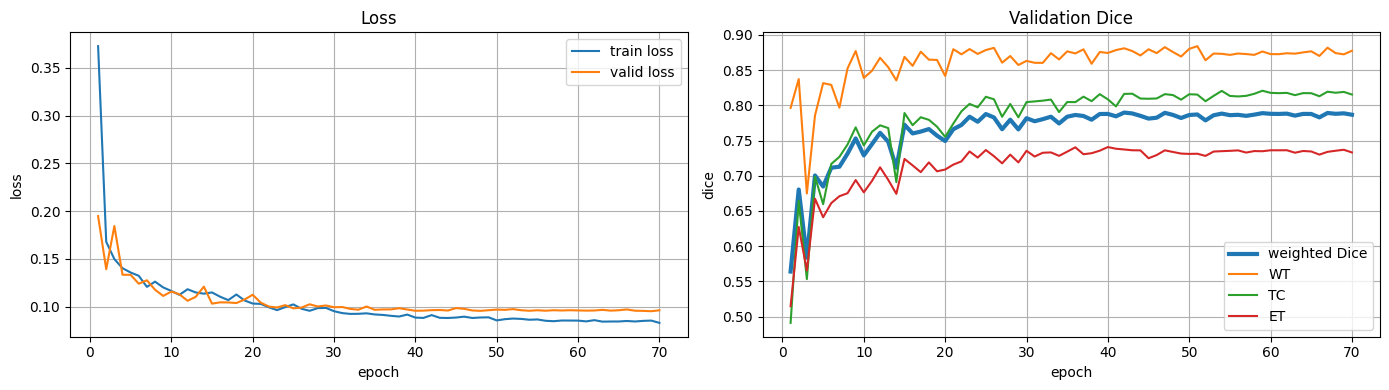

In [14]:
# Block 15: Plot training loss, validation loss, and validation Dice curves.
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='train loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], label='valid loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['valid_weighted_dice'], label='weighted Dice', linewidth=3)
plt.plot(history_df['epoch'], history_df['valid_WT_dice'], label='WT')
plt.plot(history_df['epoch'], history_df['valid_TC_dice'], label='TC')
plt.plot(history_df['epoch'], history_df['valid_ET_dice'], label='ET')
plt.xlabel('epoch')
plt.ylabel('dice')
plt.title('Validation Dice')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 16. Test Evaluation

/tmp/ipykernel_1051597/4138747655.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
               

Best epoch: 42
Best train loss: 0.091
Best validation loss: 0.0962
Best validation weighted Dice: 0.7897
Train loss at best model: 0.0873
Validation loss at best model: 0.0962
Test loss at best model: 0.0924


,split,loss
0,train,0.087345
1,valid,0.096197
2,test,0.092373


,region,dice
0,WT,0.887202
1,TC,0.854087
2,ET,0.729228


,region,dice
0,WT,0.881008
1,TC,0.816216
2,ET,0.737336


,region,dice
0,WT,0.886403
1,TC,0.818469
2,ET,0.776822


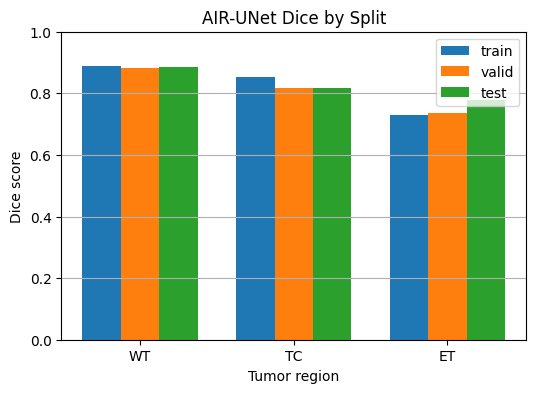

In [15]:
# Block 16: Evaluate the best model on train, validation, and test splits using the best validation checkpoint.

model = model.to(DEVICE)
criterion = criterion.to(DEVICE)

if best_checkpoint_path.exists():
    best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    best_history = pd.DataFrame(best_checkpoint['history'])
else:
    best_history = history_df.copy()

if 'valid_weighted_dice' not in best_history.columns:
    best_history['valid_weighted_dice'] = best_history.apply(
        lambda row: weighted_dice_score([row['valid_WT_dice'], row['valid_TC_dice'], row['valid_ET_dice']]),
        axis=1
    )

best_epoch_row = best_history.loc[best_history['valid_weighted_dice'].idxmax()]
best_epoch = int(best_epoch_row['epoch'])

train_loss, train_dice = run_one_epoch(model, train_loader, criterion, optimizer=None)
valid_loss, valid_dice = run_one_epoch(model, valid_loader, criterion, optimizer=None)
test_loss, test_dice = run_one_epoch(model, test_loader, criterion, optimizer=None)

train_results = pd.DataFrame({'region': REGION_NAMES, 'dice': train_dice})
valid_results = pd.DataFrame({'region': REGION_NAMES, 'dice': valid_dice})
test_results = pd.DataFrame({'region': REGION_NAMES, 'dice': test_dice})

print('Best epoch:', best_epoch)
print('Best train loss:', round(float(best_epoch_row['train_loss']), 4))
print('Best validation loss:', round(float(best_epoch_row['valid_loss']), 4))
print('Best validation weighted Dice:', round(float(best_epoch_row['valid_weighted_dice']), 4))
print('Train loss at best model:', round(train_loss, 4))
print('Validation loss at best model:', round(valid_loss, 4))
print('Test loss at best model:', round(test_loss, 4))

display(pd.DataFrame({
    'split': ['train', 'valid', 'test'],
    'loss': [train_loss, valid_loss, test_loss],
}))

display(train_results)
display(valid_results)
display(test_results)

plt.figure(figsize=(6, 4))
x = np.arange(len(REGION_NAMES))
width = 0.25

plt.bar(x - width, train_results['dice'], width=width, label='train')
plt.bar(x, valid_results['dice'], width=width, label='valid')
plt.bar(x + width, test_results['dice'], width=width, label='test')

plt.xticks(x, REGION_NAMES)
plt.ylim(0, 1)
plt.title('AIR-UNet Dice by Split')
plt.xlabel('Tumor region')
plt.ylabel('Dice score')
plt.grid(True, axis='y')
plt.legend()
plt.show()

## 17. Paper Evaluation Metrics

In [16]:
# Block 17: Tune WT, TC, and ET thresholds on validation data, then compute paper metrics.
# Dice        = 2TP / (2TP + FP + FN)
# Sensitivity = TP / (TP + FN)
# Specificity = TN / (TN + FP)
def update_binary_counts(counts, prediction, target):
    prediction = prediction.bool()
    target = target.bool()

    counts['tp'] += torch.logical_and(prediction, target).sum().item()
    counts['fp'] += torch.logical_and(prediction, ~target).sum().item()
    counts['tn'] += torch.logical_and(~prediction, ~target).sum().item()
    counts['fn'] += torch.logical_and(~prediction, target).sum().item()


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator > 0 else 0.0


def calculate_paper_metrics_from_counts(region_name, counts, split_label):
    tp = counts['tp']
    fp = counts['fp']
    tn = counts['tn']
    fn = counts['fn']

    dice = safe_divide(2 * tp, 2 * tp + fp + fn)
    sensitivity = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)

    return {
        'split': split_label,
        'region': region_name,
        'dice': dice,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
    }


def get_region_threshold(region_name, region_thresholds):
    return region_thresholds.get(region_name, PREDICTION_THRESHOLD)


def apply_hierarchical_postprocessing(predictions):
    # BraTS regions are nested: ET must be inside TC, and TC must be inside WT.
    predictions = predictions.bool().clone()

    wt_index = REGION_NAMES.index('WT')
    tc_index = REGION_NAMES.index('TC')
    et_index = REGION_NAMES.index('ET')

    predictions[:, tc_index] = predictions[:, tc_index] & predictions[:, wt_index]
    predictions[:, et_index] = predictions[:, et_index] & predictions[:, tc_index]
    return predictions


def threshold_probabilities(probabilities, region_thresholds):
    # Convert model probabilities into binary masks, then enforce ET ⊂ TC ⊂ WT.
    prediction_channels = []

    for region_index, region_name in enumerate(REGION_NAMES):
        threshold = get_region_threshold(region_name, region_thresholds)
        prediction_channels.append(probabilities[:, region_index] >= threshold)

    predictions = torch.stack(prediction_channels, dim=1)
    return apply_hierarchical_postprocessing(predictions)


def crop_to_foreground(prediction, target, margin=2):
    # Crop around the union of prediction and target to make HD95 computation faster.
    union = prediction | target

    if not union.any():
        return prediction, target

    crop_slices = []
    for axis_coordinates, axis_size in zip(np.where(union), union.shape):
        start = max(int(axis_coordinates.min()) - margin, 0)
        end = min(int(axis_coordinates.max()) + margin + 1, axis_size)
        crop_slices.append(slice(start, end))

    crop_slices = tuple(crop_slices)
    return prediction[crop_slices], target[crop_slices]


def get_surface(mask):
    if not mask.any():
        return mask

    eroded = binary_erosion(mask, structure=np.ones((3, 3, 3)), border_value=0)
    return mask ^ eroded


def calculate_hd95(prediction, target):
    # HD95 is measured in voxels in the resized 128 x 128 x 128 evaluation space.
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    if not prediction.any() and not target.any():
        return 0.0

    if not prediction.any() or not target.any():
        return float(np.linalg.norm(prediction.shape))

    prediction, target = crop_to_foreground(prediction, target)
    prediction_surface = get_surface(prediction)
    target_surface = get_surface(target)

    distance_to_target = distance_transform_edt(~target_surface)
    distance_to_prediction = distance_transform_edt(~prediction_surface)

    prediction_to_target = distance_to_target[prediction_surface]
    target_to_prediction = distance_to_prediction[target_surface]
    all_surface_distances = np.concatenate([prediction_to_target, target_to_prediction])

    return float(np.percentile(all_surface_distances, 95))


def tune_thresholds_on_validation(model, data_loader, threshold_values):
    model.eval()
    threshold_values = [float(value) for value in threshold_values]
    region_scores = {region: [] for region in REGION_NAMES}

    for threshold in threshold_values:
        metric_counts = {region: {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0} for region in REGION_NAMES}

        with torch.no_grad():
            for images, masks in tqdm(data_loader, leave=False, desc=f'Tuning threshold {threshold:.2f}'):
                images, masks = move_batch_to_device(images, masks)

                logits = model(images)
                probabilities = torch.sigmoid(logits)
                predictions = apply_hierarchical_postprocessing(probabilities >= threshold)
                targets = masks >= 0.5

                for region_index, region_name in enumerate(REGION_NAMES):
                    update_binary_counts(
                        metric_counts[region_name],
                        predictions[:, region_index],
                        targets[:, region_index]
                    )

        for region_name in REGION_NAMES:
            counts = metric_counts[region_name]
            dice = safe_divide(2 * counts['tp'], 2 * counts['tp'] + counts['fp'] + counts['fn'])
            region_scores[region_name].append({'region': region_name, 'threshold': threshold, 'valid_dice': dice})

    threshold_rows = []
    best_thresholds = {}

    for region_name in REGION_NAMES:
        rows = region_scores[region_name]
        best_row = max(rows, key=lambda row: row['valid_dice'])
        best_thresholds[region_name] = best_row['threshold']
        threshold_rows.extend(rows)

    return best_thresholds, pd.DataFrame(threshold_rows)


def calculate_paper_metrics_for_loader(model, data_loader, split_label, region_thresholds):
    model.eval()
    metric_counts = {region: {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0} for region in REGION_NAMES}
    hd95_values = {region: [] for region in REGION_NAMES}

    with torch.no_grad():
        for images, masks in tqdm(data_loader, leave=False, desc=f'Metrics {split_label}'):
            images, masks = move_batch_to_device(images, masks)

            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = threshold_probabilities(probabilities, region_thresholds)
            targets = masks >= 0.5

            for region_index, region_name in enumerate(REGION_NAMES):
                region_predictions = predictions[:, region_index]
                region_targets = targets[:, region_index]

                update_binary_counts(
                    metric_counts[region_name],
                    region_predictions,
                    region_targets
                )

                predictions_np = region_predictions.detach().cpu().numpy()
                targets_np = region_targets.detach().cpu().numpy()

                for case_index in range(predictions_np.shape[0]):
                    hd95_values[region_name].append(
                        calculate_hd95(predictions_np[case_index], targets_np[case_index])
                    )

    rows = [calculate_paper_metrics_from_counts(region, metric_counts[region], split_label) for region in REGION_NAMES]

    for row in rows:
        region = row['region']
        row['hd95_voxels'] = float(np.mean(hd95_values[region]))

    return pd.DataFrame(rows)


# Tune thresholds using validation data only.
REGION_THRESHOLDS, threshold_search_df = tune_thresholds_on_validation(model, valid_loader, THRESHOLD_SEARCH_VALUES)

print('Best thresholds selected on validation Dice:')
for region_name in REGION_NAMES:
    print(region_name, REGION_THRESHOLDS[region_name])

display(threshold_search_df.pivot(index='threshold', columns='region', values='valid_dice'))

# Compute paper metrics for train, valid, and test using tuned per-region thresholds.
train_metrics_df = calculate_paper_metrics_for_loader(model, train_loader, 'train', REGION_THRESHOLDS)
valid_metrics_df = calculate_paper_metrics_for_loader(model, valid_loader, 'valid', REGION_THRESHOLDS)
test_metrics_df = calculate_paper_metrics_for_loader(model, test_loader, 'test', REGION_THRESHOLDS)

paper_metrics_df = pd.concat([train_metrics_df, valid_metrics_df, test_metrics_df], ignore_index=True)
final_metrics_df = paper_metrics_df[['split', 'region', 'dice', 'sensitivity', 'specificity', 'hd95_voxels']]
display(final_metrics_df)

print('Metrics follow the paper formulas: Dice=2TP/(2TP+FP+FN), Sensitivity=TP/(TP+FN), Specificity=TN/(TN+FP).')
print('HD95 is the mean per-case 95th percentile Hausdorff distance in resized 128 x 128 x 128 voxel space.')
print('Hierarchical post-processing is applied: ET is forced inside TC, and TC is forced inside WT.')
print('Validation metrics use thresholds selected on validation Dice; test metrics use the same selected thresholds.')

Tuning threshold 0.30:   0%|          | 0/14 [00:00<?, ?it/s]

Best thresholds selected on validation Dice:
WT 0.51
TC 0.51
ET 0.44


region,ET,TC,WT
threshold,,,
0.30,0.840476,0.867494,0.902905
0.31,0.841532,0.868321,0.903852
0.32,0.842310,0.869073,0.904632
0.33,0.842917,0.869794,0.905479
0.34,0.843485,0.870443,0.906232
0.35,0.843752,0.871018,0.906898
0.36,0.844168,0.871569,0.907513
0.37,0.844507,0.872107,0.908096
0.38,0.844760,0.872558,0.908654


,split,region,dice,sensitivity,specificity,hd95_voxels
0,train,WT,0.900824,0.898829,0.998916,2.828851
1,train,TC,0.860555,0.868189,0.999308,2.780476
2,train,ET,0.831874,0.869472,0.999522,17.832746
3,valid,WT,0.912059,0.905184,0.999094,2.812033
4,valid,TC,0.875877,0.879863,0.999342,7.202023
5,valid,ET,0.845336,0.839729,0.999644,14.609942
6,test,WT,0.901628,0.880508,0.999201,3.002373
7,test,TC,0.843296,0.820699,0.999445,2.966342
8,test,ET,0.833351,0.897783,0.999469,14.618107


Metrics follow the paper formulas: Dice=2TP/(2TP+FP+FN), Sensitivity=TP/(TP+FN), Specificity=TN/(TN+FP).
HD95 is the mean per-case 95th percentile Hausdorff distance in resized 128 x 128 x 128 voxel space.
Hierarchical post-processing is applied: ET is forced inside TC, and TC is forced inside WT.
Validation metrics use thresholds selected on validation Dice; test metrics use the same selected thresholds.


## 18. Visualize One Prediction

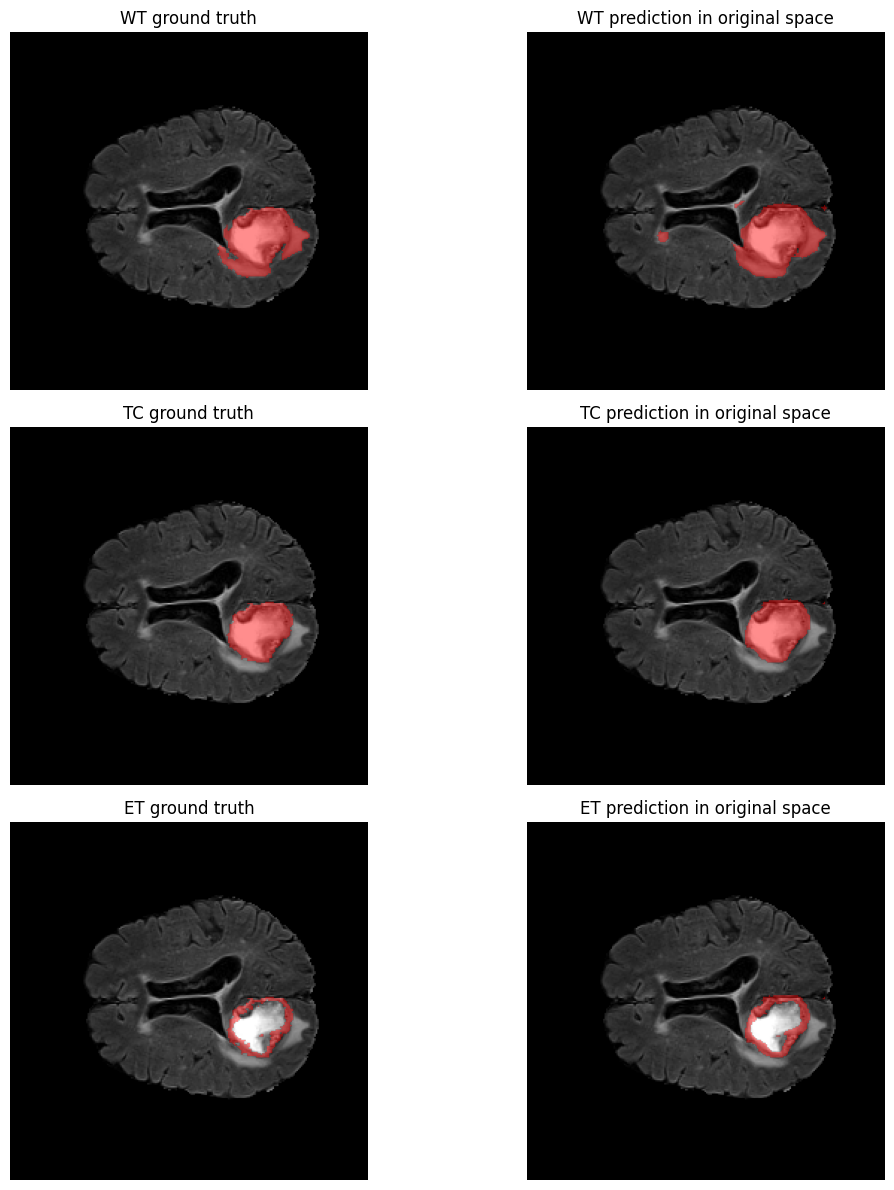

In [17]:
# Better original-space visualization using raw FLAIR for display.

model = model.to(DEVICE)
model.eval()

case_row = test_df.iloc[10]
case_folder = Path(case_row['case_folder'])

# Load raw FLAIR only for visualization
raw_flair = np.asanyarray(nib.load(case_row['flair_path']).dataobj).astype(np.float32)

# Load normalized data for model input
case_data = load_case(case_row)
original_seg = case_data['seg']
original_mask = create_region_masks(original_seg)

image_np, _ = create_resized_sample(case_data)
image_tensor = torch.from_numpy(image_np).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(image_tensor)

    orig_h, orig_w, orig_d = original_seg.shape
    logits_original = F.interpolate(
        logits,
        size=(orig_d, orig_h, orig_w),
        mode='trilinear',
        align_corners=False
    )

    probs_original = torch.sigmoid(logits_original)

prediction_np = threshold_probabilities(probs_original, REGION_THRESHOLDS)[0].cpu().numpy().astype(np.float32)
prediction_original = np.transpose(prediction_np, (0, 2, 3, 1))  # (3, H, W, D)

slice_index = int(np.argmax(original_mask[0].sum(axis=(0, 1))))
flair_slice = raw_flair[:, :, slice_index]

# Better contrast for display
brain_pixels = flair_slice[flair_slice > 0]
vmin = np.percentile(brain_pixels, 1) if len(brain_pixels) > 0 else flair_slice.min()
vmax = np.percentile(brain_pixels, 99) if len(brain_pixels) > 0 else flair_slice.max()

plt.figure(figsize=(12, 12))

for region_index, region_name in enumerate(REGION_NAMES):
    plt.subplot(3, 2, region_index * 2 + 1)
    plt.imshow(flair_slice, cmap='gray', vmin=vmin, vmax=vmax)
    plt.imshow(
        np.ma.masked_where(
            original_mask[region_index, :, :, slice_index] == 0,
            original_mask[region_index, :, :, slice_index]
        ),
        cmap='autumn',
        alpha=0.45
    )
    plt.title(f'{region_name} ground truth')
    plt.axis('off')

    plt.subplot(3, 2, region_index * 2 + 2)
    plt.imshow(flair_slice, cmap='gray', vmin=vmin, vmax=vmax)
    plt.imshow(
        np.ma.masked_where(
            prediction_original[region_index, :, :, slice_index] == 0,
            prediction_original[region_index, :, :, slice_index]
        ),
        cmap='autumn',
        alpha=0.45
    )
    plt.title(f'{region_name} prediction in original space')
    plt.axis('off')

plt.tight_layout()
plt.show()


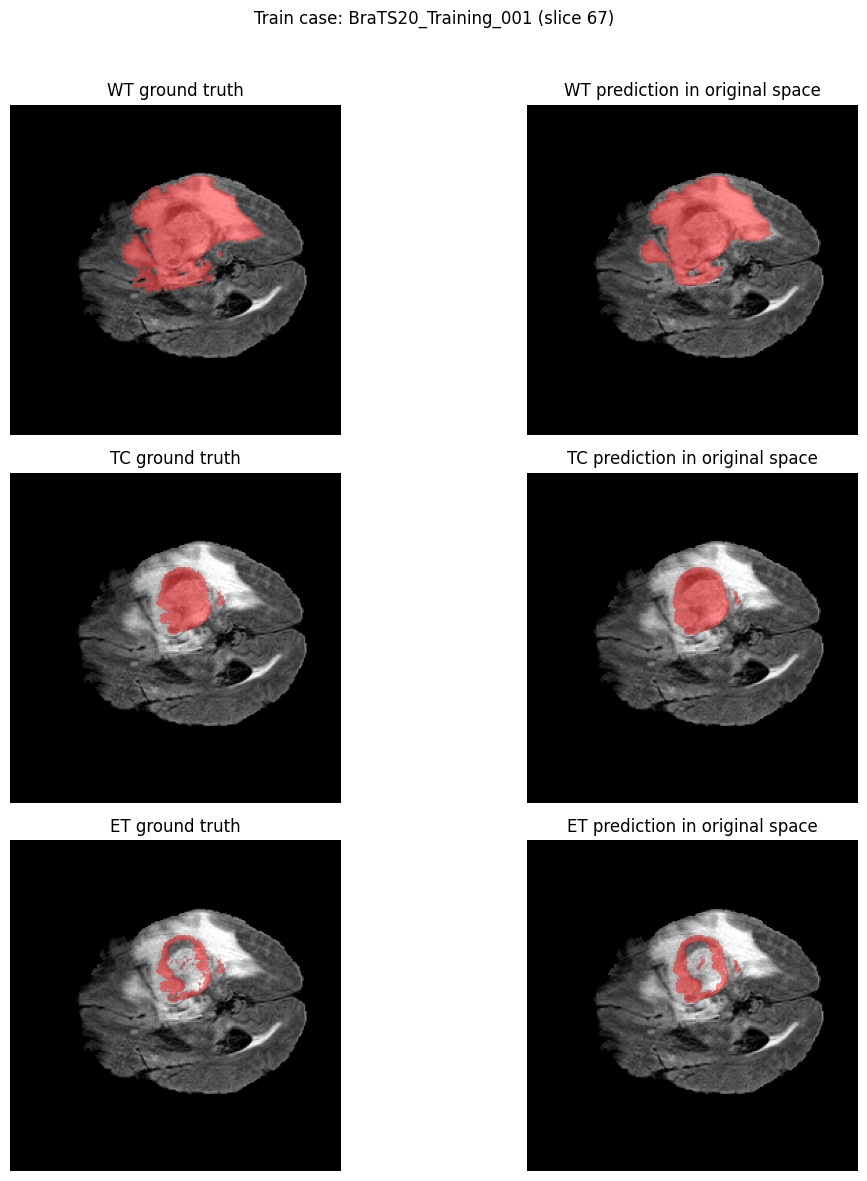

In [18]:
# Visualize one training example by explicit index
model = model.to(DEVICE)
model.eval()

example_index = 0  # change this to any valid index in train_df

case_row = train_df.iloc[example_index]

raw_flair = np.asanyarray(nib.load(case_row['flair_path']).dataobj).astype(np.float32)

case_data = load_case(case_row)
original_seg = case_data['seg']
original_mask = create_region_masks(original_seg)

image_np, _ = create_resized_sample(case_data)
image_tensor = torch.from_numpy(image_np).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(image_tensor)
    orig_h, orig_w, orig_d = original_seg.shape
    logits_original = F.interpolate(
        logits,
        size=(orig_d, orig_h, orig_w),
        mode='trilinear',
        align_corners=False
    )
    probs_original = torch.sigmoid(logits_original)

prediction_np = threshold_probabilities(probs_original, REGION_THRESHOLDS)[0].cpu().numpy().astype(np.float32)
prediction_original = np.transpose(prediction_np, (0, 2, 3, 1))

slice_index = int(np.argmax(original_mask[0].sum(axis=(0, 1))))
flair_slice = raw_flair[:, :, slice_index]

brain_pixels = flair_slice[flair_slice > 0]
vmin = np.percentile(brain_pixels, 1) if len(brain_pixels) > 0 else flair_slice.min()
vmax = np.percentile(brain_pixels, 99) if len(brain_pixels) > 0 else flair_slice.max()

plt.figure(figsize=(12, 12))
plt.suptitle(f"Train case: {case_row['case_id']} (slice {slice_index})", y=0.98)

for region_index, region_name in enumerate(REGION_NAMES):
    plt.subplot(3, 2, region_index * 2 + 1)
    plt.imshow(flair_slice, cmap='gray', vmin=vmin, vmax=vmax)
    plt.imshow(
        np.ma.masked_where(
            original_mask[region_index, :, :, slice_index] == 0,
            original_mask[region_index, :, :, slice_index]
        ),
        cmap='autumn',
        alpha=0.45
    )
    plt.title(f'{region_name} ground truth')
    plt.axis('off')

    plt.subplot(3, 2, region_index * 2 + 2)
    plt.imshow(flair_slice, cmap='gray', vmin=vmin, vmax=vmax)
    plt.imshow(
        np.ma.masked_where(
            prediction_original[region_index, :, :, slice_index] == 0,
            prediction_original[region_index, :, :, slice_index]
        ),
        cmap='autumn',
        alpha=0.45
    )
    plt.title(f'{region_name} prediction in original space')
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


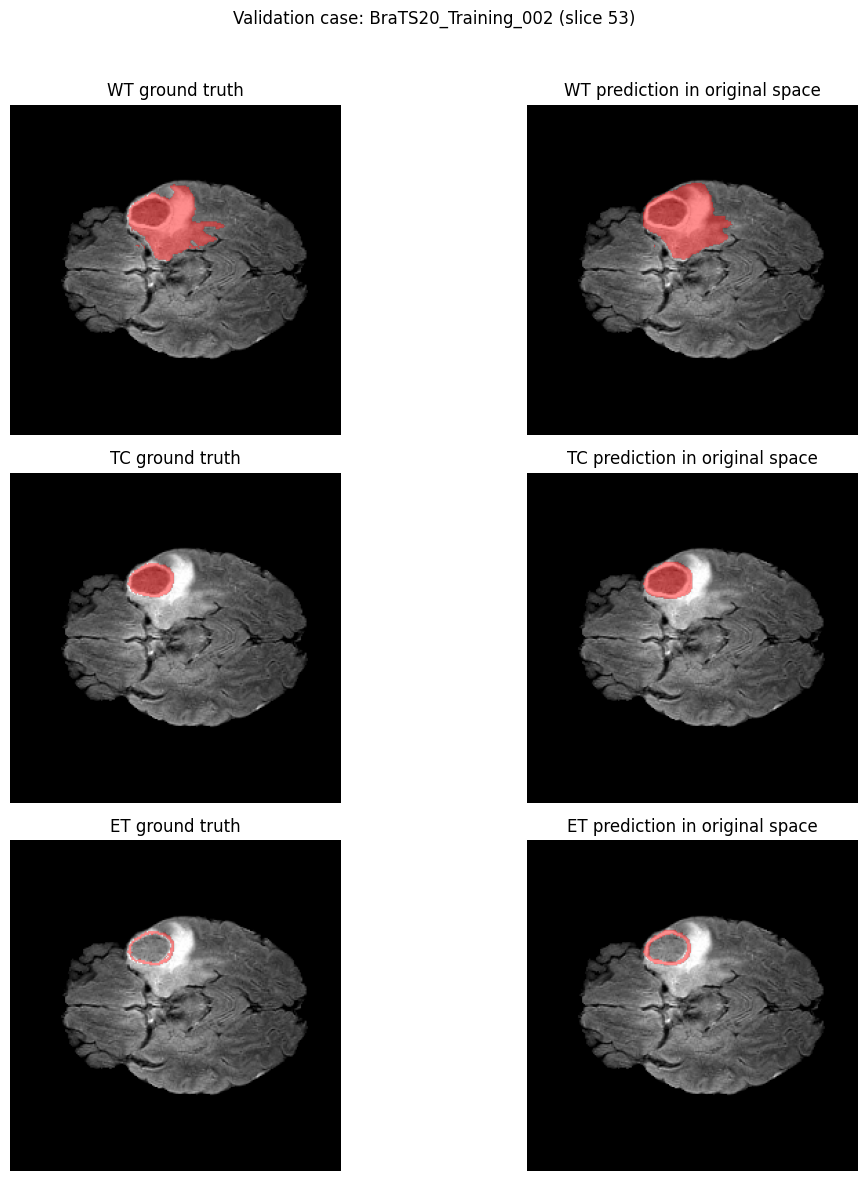

In [19]:
# Visualize one validation example by explicit index
model = model.to(DEVICE)
model.eval()

example_index = 0  # change this to any valid index in valid_df

case_row = valid_df.iloc[example_index]

raw_flair = np.asanyarray(nib.load(case_row['flair_path']).dataobj).astype(np.float32)

case_data = load_case(case_row)
original_seg = case_data['seg']
original_mask = create_region_masks(original_seg)

image_np, _ = create_resized_sample(case_data)
image_tensor = torch.from_numpy(image_np).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(image_tensor)
    orig_h, orig_w, orig_d = original_seg.shape
    logits_original = F.interpolate(
        logits,
        size=(orig_d, orig_h, orig_w),
        mode='trilinear',
        align_corners=False
    )
    probs_original = torch.sigmoid(logits_original)

prediction_np = threshold_probabilities(probs_original, REGION_THRESHOLDS)[0].cpu().numpy().astype(np.float32)
prediction_original = np.transpose(prediction_np, (0, 2, 3, 1))

slice_index = int(np.argmax(original_mask[0].sum(axis=(0, 1))))
flair_slice = raw_flair[:, :, slice_index]

brain_pixels = flair_slice[flair_slice > 0]
vmin = np.percentile(brain_pixels, 1) if len(brain_pixels) > 0 else flair_slice.min()
vmax = np.percentile(brain_pixels, 99) if len(brain_pixels) > 0 else flair_slice.max()

plt.figure(figsize=(12, 12))
plt.suptitle(f"Validation case: {case_row['case_id']} (slice {slice_index})", y=0.98)

for region_index, region_name in enumerate(REGION_NAMES):
    plt.subplot(3, 2, region_index * 2 + 1)
    plt.imshow(flair_slice, cmap='gray', vmin=vmin, vmax=vmax)
    plt.imshow(
        np.ma.masked_where(
            original_mask[region_index, :, :, slice_index] == 0,
            original_mask[region_index, :, :, slice_index]
        ),
        cmap='autumn',
        alpha=0.45
    )
    plt.title(f'{region_name} ground truth')
    plt.axis('off')

    plt.subplot(3, 2, region_index * 2 + 2)
    plt.imshow(flair_slice, cmap='gray', vmin=vmin, vmax=vmax)
    plt.imshow(
        np.ma.masked_where(
            prediction_original[region_index, :, :, slice_index] == 0,
            prediction_original[region_index, :, :, slice_index]
        ),
        cmap='autumn',
        alpha=0.45
    )
    plt.title(f'{region_name} prediction in original space')
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 19. Final Notes

This implementation follows the paper-style input preparation: each full BraTS volume is resized from `240 x 240 x 155` to `128 x 128 x 128`, then the four MRI modalities are stacked as model input. The resized normalized image and WT/TC/ET mask are cached once as `.npy` files under `data/processed`, so later epochs load ready tensors instead of repeatedly loading and resizing raw `.nii` files. The model includes the key AIR components: selected attention gates, inception-style multi-scale convolutions, and residual connections. The first encoder-to-decoder skip uses direct concatenation to preserve shallow boundary details.

In [20]:
# Block 20: Per-case ET error analysis.
# This prints the worst 10 ET cases with Dice, precision, recall, GT volume, and predicted volume.
# If predicted ET volume is much larger than GT volume, the model has false positives.
# If predicted ET volume is much smaller than GT volume, the model is missing ET regions.

ERROR_ANALYSIS_SPLIT = 'test'  # options: 'train', 'valid', 'test'
ERROR_ANALYSIS_TOP_K = 10


def calculate_case_scores(prediction, target):
    prediction = prediction.bool()
    target = target.bool()

    true_positive = torch.logical_and(prediction, target).sum().item()
    false_positive = torch.logical_and(prediction, ~target).sum().item()
    false_negative = torch.logical_and(~prediction, target).sum().item()

    dice_denominator = 2 * true_positive + false_positive + false_negative
    predicted_positive = true_positive + false_positive
    actual_positive = true_positive + false_negative

    if predicted_positive == 0 and actual_positive == 0:
        return 1.0, 1.0, 1.0, true_positive, false_positive, false_negative

    dice = safe_divide(2 * true_positive, dice_denominator)
    precision = safe_divide(true_positive, predicted_positive)
    recall = safe_divide(true_positive, actual_positive)

    return dice, precision, recall, true_positive, false_positive, false_negative


def describe_et_error(gt_volume, predicted_volume):
    if gt_volume == 0 and predicted_volume == 0:
        return 'no ET in GT and prediction'
    if gt_volume == 0 and predicted_volume > 0:
        return 'false positive ET on no-ET case'
    if gt_volume > 0 and predicted_volume == 0:
        return 'missed all ET'

    volume_ratio = predicted_volume / gt_volume

    if volume_ratio > 1.25:
        return 'over-prediction / false positives'
    if volume_ratio < 0.75:
        return 'under-prediction / missed ET'
    return 'similar volume, check boundary/location'


def get_error_analysis_dataframe(split_label):
    split_dataframes = {
        'train': train_df,
        'valid': valid_df,
        'test': test_df,
    }

    if split_label not in split_dataframes:
        raise ValueError("ERROR_ANALYSIS_SPLIT must be one of: 'train', 'valid', 'test'")

    return split_dataframes[split_label].reset_index(drop=True)


if best_checkpoint_path.exists():
    best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print('Loaded best checkpoint for ET error analysis:', best_checkpoint_path)
else:
    print('Best checkpoint not found. Using the current model weights for ET error analysis.')

model = model.to(DEVICE)
model.eval()

analysis_df = get_error_analysis_dataframe(ERROR_ANALYSIS_SPLIT)
analysis_dataset = BraTSCachedVolumeDataset(analysis_df, ERROR_ANALYSIS_SPLIT, training=False)
analysis_loader = DataLoader(
    analysis_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

et_index = REGION_NAMES.index('ET')
et_threshold = get_region_threshold('ET', REGION_THRESHOLDS)
case_rows = []

with torch.no_grad():
    for case_index, (images, masks) in enumerate(tqdm(analysis_loader, desc=f'ET error analysis {ERROR_ANALYSIS_SPLIT}')):
        images, masks = move_batch_to_device(images, masks)

        logits = model(images)
        probabilities = torch.sigmoid(logits)
        predictions = threshold_probabilities(probabilities, REGION_THRESHOLDS)

        et_prediction = predictions[:, et_index]
        et_target = masks[:, et_index] >= 0.5

        dice, precision, recall, tp, fp, fn = calculate_case_scores(et_prediction, et_target)
        gt_volume = int(et_target.sum().item())
        predicted_volume = int(et_prediction.sum().item())

        case_rows.append({
            'split': ERROR_ANALYSIS_SPLIT,
            'case_id': analysis_df.iloc[case_index]['case_id'],
            'ET_dice': dice,
            'ET_precision': precision,
            'ET_recall': recall,
            'ET_gt_volume_voxels': gt_volume,
            'ET_predicted_volume_voxels': predicted_volume,
            'ET_volume_difference': predicted_volume - gt_volume,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'main_error': describe_et_error(gt_volume, predicted_volume),
        })

et_case_analysis_df = pd.DataFrame(case_rows).sort_values('ET_dice', ascending=True).reset_index(drop=True)
worst_et_cases_df = et_case_analysis_df.head(ERROR_ANALYSIS_TOP_K)

print('ET threshold used:', et_threshold)
print('Worst', ERROR_ANALYSIS_TOP_K, 'ET cases from', ERROR_ANALYSIS_SPLIT, 'split:')
display(worst_et_cases_df)

print('Use ET_volume_difference and main_error to decide the fix:')
print('- Positive volume difference means predicted ET is larger than GT, usually false positives.')
print('- Negative volume difference means predicted ET is smaller than GT, usually missed ET.')


/tmp/ipykernel_1051597/3553019794.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)


Loaded best checkpoint for ET error analysis: /home/charlie/dan/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_best.pt


ET error analysis test:   0%|          | 0/55 [00:00<?, ?it/s]

ET error analysis test: 100%|██████████| 55/55 [00:05<00:00,  9.72it/s]

ET threshold used: 0.44
Worst 10 ET cases from test split:


,split,case_id,ET_dice,ET_precision,ET_recall,ET_gt_volume_voxels,ET_predicted_volume_voxels,ET_volume_difference,tp,fp,fn,main_error
0,test,BraTS20_Training_297,0.000000,0.000000,0.000000,0,17,17,0,17,0,false positive ET on no-ET case
1,test,BraTS20_Training_321,0.000000,0.000000,0.000000,0,12,12,0,12,0,false positive ET on no-ET case
2,test,BraTS20_Training_304,0.000000,0.000000,0.000000,0,4,4,0,4,0,false positive ET on no-ET case
3,test,BraTS20_Training_291,0.129032,0.075269,0.451613,31,186,155,14,172,17,over-prediction / false positives
4,test,BraTS20_Training_273,0.360817,0.225154,0.907801,282,1137,855,256,881,26,over-prediction / false positives
5,test,BraTS20_Training_280,0.393048,0.252144,0.890909,165,583,418,147,436,18,over-prediction / false positives
6,test,BraTS20_Training_301,0.435877,0.340086,0.606791,913,1629,716,554,1075,359,over-prediction / false positives
7,test,BraTS20_Training_238,0.486126,0.322873,0.983317,9051,27565,18514,8900,18665,151,over-prediction / false positives
8,test,BraTS20_Training_318,0.541596,0.417539,0.770531,414,764,350,319,445,95,over-prediction / false positives
9,test,BraTS20_Training_058,0.599686,0.501532,0.745608,1537,2285,748,1146,1139,391,over-prediction / false positives


Use ET_volume_difference and main_error to decide the fix:
- Positive volume difference means predicted ET is larger than GT, usually false positives.
- Negative volume difference means predicted ET is smaller than GT, usually missed ET.
